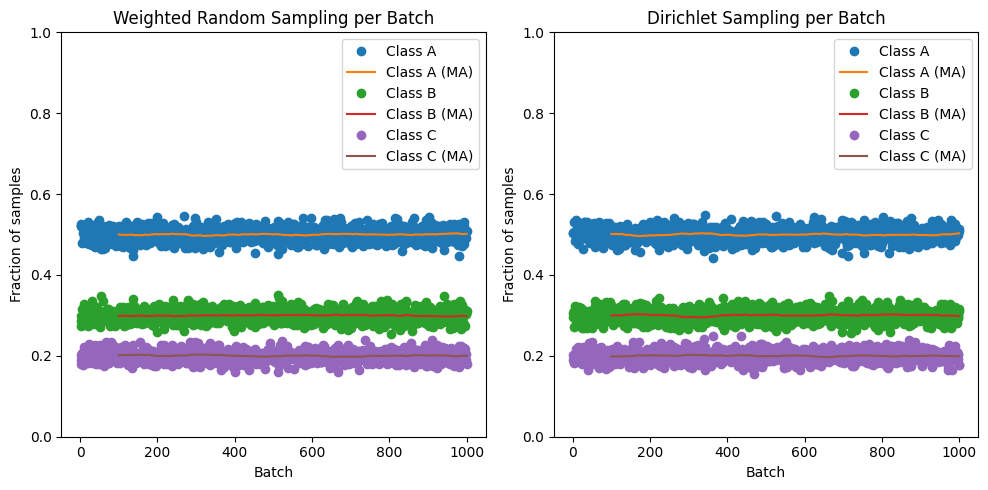

wrs
mean: [0.500074 0.299646 0.20028 ]
stdev: [0.01602263 0.01472945 0.01294749]
dir
mean: [0.500035 0.30005  0.199915]
stdev: [0.01614942 0.01499758 0.01358138]


In [48]:
import numpy as np
import matplotlib.pyplot as plt

# Settings
classes = ['A', 'B', 'C']
num_batches = 1000
samples_per_batch = 1000

# Weighted Random Sampling probabilities
wrs_probs = np.array([0.5, 0.3, 0.2])

# Dirichlet Sampling concentration parameters
alpha = np.array([5000, 3000, 2000])

# Collect batch class distributions
wrs_batches = []
dir_batches = []

for _ in range(num_batches):
    # WRS: sample each batch according to fixed probabilities
    wrs_sample = np.random.choice(classes, size=samples_per_batch, p=wrs_probs)
    wrs_counts = [np.sum(wrs_sample == c)/samples_per_batch for c in classes]
    wrs_batches.append(wrs_counts)
    
    # Dirichlet: sample probability vector then sample batch
    dir_p = np.random.dirichlet(alpha)
    dir_sample = np.random.choice(classes, size=samples_per_batch, p=dir_p)
    dir_counts = [np.sum(dir_sample == c)/samples_per_batch for c in classes]
    dir_batches.append(dir_counts)

wrs_batches = np.array(wrs_batches)
dir_batches = np.array(dir_batches)

n=100

def moving_average(a, n=3):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

# Plot
plt.figure(figsize=(10,5))
x = np.arange(1, num_batches+1)

plt.subplot(1,2,1)
for i, c in enumerate(classes):
    plt.plot(x, wrs_batches[:,i], marker='o', label=f'Class {c}', linestyle='none')
    plt.plot(x[(n-1):], moving_average(wrs_batches[:,i], n=n), marker='none', label=f'Class {c} (MA)', linestyle='-')

plt.title('Weighted Random Sampling per Batch')
plt.xlabel('Batch')
plt.ylabel('Fraction of samples')
plt.ylim(0,1)
plt.legend()

plt.subplot(1,2,2)
for i, c in enumerate(classes):
    plt.plot(x, dir_batches[:,i], marker='o', label=f'Class {c}', linestyle='none')
    plt.plot(x[(n-1):], moving_average(dir_batches[:,i], n=n), marker='none', label=f'Class {c} (MA)', linestyle='-')
plt.title('Dirichlet Sampling per Batch')
plt.xlabel('Batch')
plt.ylabel('Fraction of samples')
plt.ylim(0,1)
plt.legend()

plt.tight_layout()
plt.show()

# print(wrs_batches)
print('wrs')
print('mean:',np.mean(wrs_batches,0))
print('stdev:',np.std(wrs_batches,0))

# print(dir_batches)
print('dir')
print('mean:',np.mean(dir_batches,0))
print('stdev:',np.std(dir_batches,0))
